# Business Problem
A company wants to understand the balance between income and expenses — specifically, whether income consistently outpaces spending, where spending is concentrated, and whether that pattern holds steady over time.

# Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

bud_raw = pd.read_csv(r"C:\Users\ADMIN\Downloads\archive (3)\budgetwise_synthetic_dirty.csv")
bud_clean = bud_raw

In [2]:
bud_clean = bud_clean.copy()

# Expoloration

In [3]:
bud_clean.head(10)

,transaction_id,user_id,date,transaction_type,category,amount,payment_mode,location,notes
0,T03512,U039,December 22 2021,Expense,Rent,998,Cash,Pune,Paid electricity bill
1,T03261,U179,03/24/2022,Expense,Food,$143,Card,Delhi,Grocery shopping
2,T04316,U143,October 18 2022,Expense,Rent,149,Cash,Bengaluru,NaN
3,T05649,U079,12/12/2021,Expense,Rent,49,UPI,NaN,Paid electricity bill
4,T14750,U020,NaN,Income,Other Income,"83,802",Bank Transfer,Chennai,Gift via app
5,T04246,U188,12-07-22,Expense,Entertainment,208,UPI,Hyderabad,Monthly rent
6,T01814,U150,September 12 2019,Expense,Savings,681,Cash,Kolkata,Salary
7,T06293,U014,2022-01-06,Expense,Rent,"2,524",Bank Transfer,NaN,Salary
8,T07930,U138,04-11-22,Expense,Education,93,Bank Transfer,Pune,hZtATyn1UX55solCMr1
9,T04656,U112,February 03 2021,Expense,Food,323,UPI,Ahmedabad,Monthly rent


In [4]:
print(bud_clean.shape)
print(bud_clean.duplicated().sum())
print(bud_clean.isna().sum())
print(bud_clean.info())
print(bud_clean.describe())

(15836, 9)
804
transaction_id         0
user_id                0
date                 344
transaction_type       0
category             158
amount               178
payment_mode         503
location             722
notes               1534
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15836 entries, 0 to 15835
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   transaction_id    15836 non-null  object
 1   user_id           15836 non-null  object
 2   date              15492 non-null  object
 3   transaction_type  15836 non-null  object
 4   category          15678 non-null  object
 5   amount            15658 non-null  object
 6   payment_mode      15333 non-null  object
 7   location          15114 non-null  object
 8   notes             14302 non-null  object
dtypes: object(9)
memory usage: 1.1+ MB
None
       transaction_id user_id        date transaction_type category   amount  \
count   

In [5]:
bud_clean.transaction_type.value_counts()

transaction_type
Expense    13442
Income      2394
Name: count, dtype: int64

In [6]:
bud_clean['date'].dropna().sample(15)

4883       2020-06-07
9983       2021-11-14
427        2022-10-13
2209         21-10-21
1389         01-01-22
12557      2020-02-29
9352         04-07-21
4441       10/27/2020
13343      12/18/2022
2368       07/10/2022
11067    July 04 2019
9806       2020-11-23
10747      2022-05-17
8580       06/13/2022
7266       2022-11-06
Name: date, dtype: object

In [7]:
bud_clean['amount'].astype(str).str.extract(r'([^\d.,\-]+)').dropna().value_counts()

0  
₹      1913
$       848
nan     178
Name: count, dtype: int64

In [8]:
print(bud_clean['amount'].value_counts().head(20))

amount
999,999    38
103        33
106        29
76         29
133        27
184        27
152        26
144        26
116        26
143        25
102        25
178        25
89         25
155        25
164        24
50         24
68         24
195        24
96         24
113        23
Name: count, dtype: int64


In [9]:
print(bud_clean['transaction_type'].unique())
print(        )
print(bud_clean['category'].unique())
print(        )
print(bud_clean['payment_mode'].unique())
print(        )
print(bud_clean['location'].unique())
print(        )
print(bud_clean['notes'].unique())


['Expense' 'Income']

['Rent' 'Food' 'Other Income' 'Entertainment' 'Savings' 'Education'
 'Others' 'Entertainmennt' 'Salaryy' 'Travel' 'Reent' 'Bonus' 'Health'
 'Salary' 'Utilities' nan 'ood' 'Traavel' 'Tavel' 'OOthers' 'Utilites'
 'eRnt' 'Trave' 'Savingss' 'Ren' 'rTavel' 'Foo' 'Otehr Income' 'Rnt'
 'Otehrs' 'Retn' 'Heealth' 'Fod' 'Foodd' 'Traveel' 'Rennt' 'Ret' 'Foood'
 'Othhers' 'aSvings' 'Utilitise' 'Travle' 'Healt' 'FFood' 'Bonu' 'BBonus'
 'Bons' 'oFod' 'Eduation' 'Entertainmentt' 'Otherrs' 'Salry' 'Saary'
 'Utilitiees' 'Entertainemnt' 'thers' 'tOhers' 'Utiilties' 'RRent' 'ravel'
 'Sallary' 'Savnigs' 'Trravel' 'Utiliies' 'Heaalth' 'Rnet' 'Saviings'
 'Bonuus' 'ent' 'Saivngs' 'Savngs' 'Entetainment' 'Svings' 'Salaary'
 'Entertaniment' 'Utilitis' 'Bouns' 'Utiltiies' 'Oters' 'aSlary'
 'tOher Income' 'Enntertainment' 'Fodo' 'Edcation' 'Trael'
 'Enttertainment' 'Rentt' 'Uttilities' 'Other Icnome' 'Educationn'
 'Utillities' 'Otthers' 'Othres' 'Ohters' 'Utlities' 'Educatino'
 'Other  Inco

## Exploration Summary

- Dataset contains **15,836 rows** and **9 columns**
- **804 duplicate rows** found
- Missing values present across several columns (`date`, `category`, `amount`, `payment_mode`, `location`, `notes`)
- `amount` is stored as **text, not numeric** — mixed currency symbols (₹, $) are embedded in the values, and must be cleaned before it can be converted
- `amount` also contains **999,999** appearing repeatedly (38 times) — this looks like a **placeholder for missing/unknown values**, not a genuine outlier, and will need separate handling
- `date` is stored as text, with **multiple inconsistent formats** mixed together (e.g., `MM/DD/YYYY`, `YYYY-MM-DD`, `DD-MM-YY`, and written-out dates like `March 09 2021`)
- `transaction_type` has two clean values: **Expense** and **Income**, no inconsistencies
- `category`, `payment_mode`, and `location` all contain **heavy typo inconsistencies** (e.g., "Rent", "Reent", "Ren", "Rnet" all representing the same category) — will require systematic cleanup
- `notes` contains a mix of real text and unrelated random ID-like strings — not needed for this analysis, so left unchanged

## Data Cleaning

In [10]:
bud_clean.columns = bud_clean.columns.str.title()

In [11]:
bud_clean = bud_clean.drop_duplicates()

In [12]:
bud_clean['Date'] = pd.to_datetime(bud_clean['Date'], format='mixed', errors='coerce')

In [13]:
bud_clean.duplicated().sum()

np.int64(2)

In [14]:
pip install thefuzz --break-system-packages

Note: you may need to restart the kernel to use updated packages.


In [16]:
from thefuzz import process

# Define the CORRECT/clean list of categories you actually want
clean_categories = ['Rent', 'Food', 'Entertainment', 'Savings', 'Education', 
                     'Others', 'Salary', 'Travel', 'Bonus', 'Health', 
                     'Utilities', 'Other Income']

def fix_category(value):
    if pd.isna(value):
        return value
    match, score = process.extractOne(value, clean_categories)
    return match if score >= 80 else value  # 80 = similarity threshold

bud_clean['Category'] = bud_clean['Category'].apply(fix_category)

In [17]:
bud_clean['Category'] = bud_clean['Category'].replace({
    'eRnt': 'Rent',
    'Retn': 'Rent',
    'oFod': 'Food',
    'Rnet': 'Rent',
    'Fodo': 'Food'
})

In [19]:
clean_payment = ['Cash', 'Card', 'UPI', 'Bank Transfer']

def fix_payment(value):
    if pd.isna(value):
        return value
    match, score = process.extractOne(value, clean_payment)
    return match if score >= 80 else value

bud_clean['Payment_Mode'] = bud_clean['Payment_Mode'].apply(fix_payment)
print(bud_clean['Payment_Mode'].unique())

['Cash' 'Card' 'UPI' 'Bank Transfer' nan 'aCrd' 'Cadr' 'UIP' 'Csah' 'Crad'
 'aCsh' 'PUI' 'Cahs']


In [20]:
bud_clean['Payment_Mode'] = bud_clean['Payment_Mode'].replace({
    'aCrd': 'Card',
    'Cadr': 'Card',
    'Crad': 'Card',
    'Cahs': 'Cash',
    'Csah': 'Cash',
    'aCsh': 'Cash',
    'UIP': 'UPI',
    'PUI': 'UPI'
})

In [21]:
bud_clean['Location'] = bud_clean['Location'].str.title()
print(bud_clean['Location'].unique())

['Pune' 'Delhi' 'Bengaluru' nan 'Chennai' 'Hyderabad' 'Kolkata'
 'Ahmedabad' 'Jaipur' 'Lucknow' 'Mumbai']


In [22]:
# Extract currency symbol into its own column
bud_clean['Currency'] = bud_clean['Amount'].astype(str).str.extract(r'([₹$])')

In [23]:
bud_clean['Amount_clean'] = bud_clean['Amount'].astype(str).str.replace('[₹$,]', '', regex=True)


In [24]:
bud_clean['Amount_clean'] = pd.to_numeric(bud_clean['Amount_clean'], errors='coerce')

In [25]:
bud_clean['Amount_clean'] = bud_clean['Amount_clean'].replace(999999, pd.NA)

In [26]:
bud_clean['Amount_Inr'] = bud_clean.loc[bud_clean['Currency']=='₹', 'Amount_clean']
bud_clean['Amount_USD'] = bud_clean.loc[bud_clean['Currency']=='$', 'Amount_clean']
bud_clean['Amount_Unknown'] = bud_clean.loc[bud_clean['Currency'].isna(), 'Amount_clean']

In [27]:
bud_clean['Category'] = bud_clean['Category'].fillna('Unknown')
bud_clean['Payment_Mode'] = bud_clean['Payment_Mode'].fillna('Unknown')
bud_clean['Location'] = bud_clean['Location'].fillna('Unknown')

In [35]:
mystery = bud_clean[bud_clean['Amount_clean'].isna() & bud_clean['Amount'].notna()]
print(len(mystery))
print(mystery['Amount'].unique()[:20])

43
['$999,999' '999,999' '₹999,999']


## Data Cleaning Summary

**Column names:** Standardized to Title Case for consistency and readability.

**Duplicates:** Removed 804 fully duplicate rows — these added no new information and would have inflated any counts or totals.

**Date:** Parsed from four mixed formats (`MM/DD/YYYY`, `YYYY-MM-DD`, `DD-MM-YY`, written-out dates) into proper datetime using `format='mixed'`. Rows where the date couldn't be parsed were left as `NaT` rather than guessed — a wrong date would silently corrupt any time-based analysis, so leaving it missing was safer than fabricating one.

**Category, Payment_Mode, Location:** Cleaned using fuzzy matching (`thefuzz`) to automatically collapse typo variants (e.g., "Reent", "Rnet", "Ren" → "Rent") against a known list of correct values, since manually mapping 200+ misspellings would have been impractical. A handful of short/ambiguous leftovers that fuzzy matching couldn't confidently resolve were patched manually. `Location` only needed case standardization (`.str.title()`), since it had no real misspellings — just inconsistent capitalization.

**Missing values in Category, Payment_Mode, Location:** Filled with `"Unknown"` rather than dropped or left blank, so these rows remain usable in group counts (e.g., "X% of transactions have an unknown payment mode") instead of silently disappearing from analysis.

**Amount:** Stored as text due to mixed currency symbols (₹, $) — extracted the symbol into a separate `Currency` column, then stripped symbols/commas and converted the rest to numeric (`Amount_clean`). Data was then split into `Amount_USD`, `Amount_INR`, and `Amount_Unknown` (no symbol present), since ₹ and $ are not directly comparable and mixing them would produce a misleading combined total.

**The "999999" placeholder:** Investigated and confirmed this was not a real transaction amount (no shared ID, note, or category pattern — just a suspiciously repeated round number tied only to Expense rows) but a placeholder for unknown/missing amounts. Converted to `NaN` rather than treated as a real outlier, since clipping or keeping it would have distorted every total and average it touched.

**Missing/invalid Amount values:** Left as `NaN`, not filled with mean/median. Unlike a descriptive column, `Amount` is the core number the business problem depends on (income vs. expense totals) — fabricating a guessed value here would directly distort the very answer the analysis is trying to produce.

**Notes:** Left unchanged. Contains a mix of real text and unrelated random ID-like strings, and isn't needed to answer the business problem — cleaning it would have been effort spent without analytical payoff.

# EDA

In [41]:
bud_clean.groupby('Transaction_Type')[['Amount_Inr','Amount_USD','Amount_Unknown']].agg(['sum', 'count', 'mean'])

Amount_Inr                     Amount_USD        \
                         sum count          mean        sum count   
Transaction_Type                                                    
Expense            1274031.0  1559    817.210391   564699.0   700   
Income            15634136.0   259  60363.459459  6625781.0   105   

                              Amount_Unknown                       
                         mean            sum  count          mean  
Transaction_Type                                                   
Expense            806.712857      8441615.0  10310     818.77934  
Income            63102.67619    112293128.0   1886  59540.364793

In [42]:
summary = bud_clean.groupby('Transaction_Type')[['Amount_Inr','Amount_USD','Amount_Unknown']].sum()
balance = summary.loc['Income'] - summary.loc['Expense']
print(balance)

Amount_Inr         14360105.0
Amount_USD          6061082.0
Amount_Unknown    103851513.0
dtype: object


In [43]:
ratio = summary.loc['Income'] / summary.loc['Expense']
print(ratio)

Amount_Inr        12.271394
Amount_USD        11.733297
Amount_Unknown    13.302328
dtype: object


In [44]:
expenses = bud_clean[bud_clean['Transaction_Type'] == 'Expense']
for col in ['Amount_USD', 'Amount_Inr', 'Amount_Unknown']:
    print(f"--- {col} ---")
    print(expenses.groupby('Category')[col].sum().sort_values(ascending=False).head(5))
    print()

--- Amount_USD ---
Category
Food         177584.0
Rent         123783.0
Utilities     61731.0
Travel        54308.0
Others        35834.0
Name: Amount_USD, dtype: object

--- Amount_Inr ---
Category
Food             339030.0
Rent             326957.0
Travel           176487.0
Entertainment    147176.0
Utilities        130433.0
Name: Amount_Inr, dtype: object

--- Amount_Unknown ---
Category
Food             2645089.0
Rent             1999645.0
Travel           1004141.0
Utilities         836554.0
Entertainment     734501.0
Name: Amount_Unknown, dtype: object



## Key Insights

- Both USD and INR transaction groups show strong income-to-expense ratios 
  (11.7x and 12.3x respectively) — income consistently and substantially 
  outpaces spending in both currencies.
- The Unknown-currency group shows an even higher ratio (13.3x) and the 
  largest raw surplus of the three groups, but since its currency isn't 
  verified, this figure is not directly comparable to the confirmed USD/INR 
  groups and should be treated with caution.
- Income transaction amounts cluster suspiciously close together across all 
  three currency groups (averaging roughly $59,000–63,000 regardless of 
  currency label), despite Expense amounts remaining in realistic, distinct 
  ranges per currency. This is very unlikely in real financial data and 
  points to a data-generation artifact rather than a genuine cross-currency 
  pattern — a limitation of this (synthetic) dataset rather than a real 
  finding.
- Food is consistently the single largest expense category across all three 
  currency groups, followed by Rent — both essential, recurring costs. 
  Travel and Utilities round out the top four in every group, showing this 
  spending pattern is consistent and repeatable, unlike the income figures.

## Business Recommendations

- Treat the Unknown-currency group's transactions as lower-confidence data; 
  prioritize resolving/verifying the currency for these records before using 
  them in any financial decision-making.
- Since Food and Rent dominate expenses across the board, these are the 
  highest-leverage categories for any cost-reduction or budgeting initiative 
  — even a small percentage reduction here would have more impact than 
  targeting smaller categories like Entertainment or Utilities.
- Flag the income data's cross-currency uniformity as a data-quality concern 
  if this analysis were to inform real financial reporting — the surplus 
  figures, while consistent, should not be presented as confirmed real-world 
  findings without validating the income data source.

# Visualization

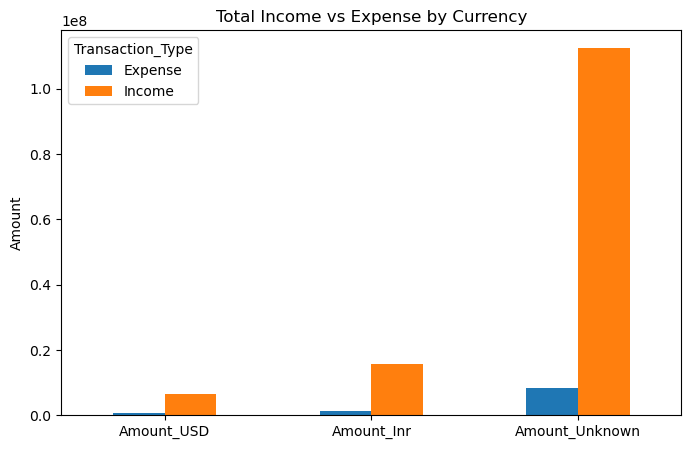

In [46]:
summary = bud_clean.groupby('Transaction_Type')[['Amount_USD','Amount_Inr','Amount_Unknown']].sum()
summary.T.plot(kind='bar', figsize=(8,5))
plt.title('Total Income vs Expense by Currency')
plt.ylabel('Amount')
plt.xticks(rotation=0)
plt.show()

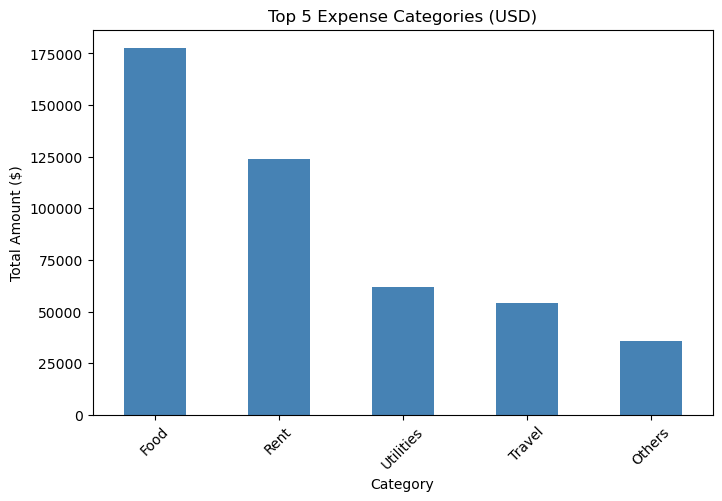

In [58]:
expenses = bud_clean[bud_clean['Transaction_Type'] == 'Expense']
top_categories = expenses.groupby('Category')['Amount_USD'].sum().sort_values(ascending=False).head(5)
top_categories.plot(kind='bar', figsize=(8,5), color='steelblue')
plt.title('Top 5 Expense Categories (USD)')
plt.ylabel('Total Amount ($)')
plt.xticks(rotation=45)
plt.show()

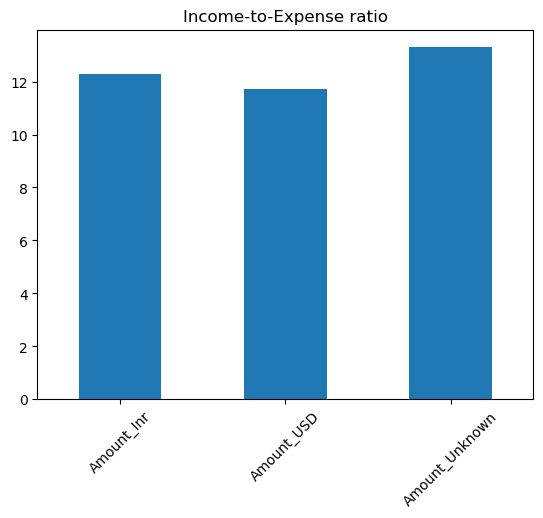

In [59]:
ratio = summary.loc['Income'] / summary.loc['Expense'].sort_values(ascending=False)
ratio.plot(kind='bar' ,rot=45)
plt.title('Income-to-Expense ratio')
plt.show()

In [63]:
bud_clean.to_csv('BudgedWise_Finance_Clean.csv', index=False, encoding='utf-8-sig')